## Early exploration of tasseled cap coefficients

- https://github.com/opendatacube/odc-stats/blob/develop/odc/stats/plugins/tcw_percentiles.py

- See runbooks for TCP documentation

- Current TC coefficients are stored in the twc percentiles plugin for odc-stats (see above)

TODO/ To explore:

- calculating the TC coeffs directly from the Landsat ARD data, by sensor (so L5, L7, and L8/9)

In [167]:
import datacube
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box, shape, MultiPolygon, MultiLineString
import matplotlib.pyplot as plt
import cartopy
from datacube.utils.masking import make_mask, mask_invalid_data
from odc.algo import mask_cleanup
from odc.algo._percentile import xr_quantile_bands
from odc.algo._masking import _xr_fuse, _fuse_mean_np, enum_to_bool, mask_cleanup
from odc.geo.xr import assign_crs
from odc.geo.geom import Geometry
import warnings
import json

import sys
#sys.path.insert(1, '/home/jovyan/git/dea-notebooks/Tools/')
sys.path.insert(1, '.../Tools')
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster
from dea_tools.bandindices import   calculate_indices

warnings.filterwarnings("ignore")

In [168]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/38041/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/38041/status,Workers: 1
Total threads: 3,Total memory: 28.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46275,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/38041/status,Total threads: 3
Started: Just now,Total memory: 28.21 GiB
Comm: tcp://127.0.0.1:37139,Total threads: 3
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/35791/status,Memory: 28.21 GiB
Nanny: tcp://127.0.0.1:43051,


## Analysis params



Note that the existing coefficients are from Crist (1985).

In [169]:
# current tc coefficients used in odc-stats

tc_coefficients = dict(
                [
                    (
                        "wet",
                        dict(
                            [
                                ("blue", 0.0315),
                                ("green", 0.2021),
                                ("red", 0.3102),
                                ("nir", 0.1594),
                                ("swir1", -0.6806),
                                ("swir2", -0.6109),
                            ]
                        ),
                    ),
                    (
                        "bright",
                        dict(
                            [
                                ("blue", 0.2043),
                                ("green", 0.4158),
                                ("red", 0.5524),
                                ("nir", 0.5741),
                                ("swir1", 0.3124),
                                ("swir2", 0.2303),
                            ]
                        ),
                    ),
                    (
                        "green",
                        dict(
                            [
                                ("blue", -0.1603),
                                ("green", -0.2819),
                                ("red", -0.4934),
                                ("nir", 0.7940),
                                ("swir1", -0.0002),
                                ("swir2", -0.1446),
                            ]
                        ),
                    ),
                ]
            )

Landsat 8/9 coefficients used by Hexagon and from the literature, more recent coefficients than the Crist ones used in WIT.

Source: Baig, M. H. A., Zhang, L., Shuai, T., & Tong, Q. (2014). Derivation of a tasselled cap transformation based on Landsat 8 at-satellite reflectance. Remote Sensing Letters, 5(5), 423-431.

In [170]:
tc_ls8ls9_coefficients = dict(
                [
                    (
                        "wet",
                        dict(
                            [
                                ("blue", 0.1511),
                                ("green", 0.1973),
                                ("red", 0.3283),
                                ("nir", 0.3407),
                                ("swir1", -0.7117),
                                ("swir2", -0.4559),
                            ]
                        ),
                    ),
                    (
                        "bright",
                        dict(
                            [
                                ("blue", 0.3029),
                                ("green", 0.2786),
                                ("red", 0.4733),
                                ("nir", 0.5599),
                                ("swir1", 0.5080),
                                ("swir2", 0.1872),
                            ]
                        ),
                    ),
                    (
                        "green",
                        dict(
                            [
                                ("blue", -0.2941),
                                ("green", -0.2430),
                                ("red", -0.5424),
                                ("nir", 0.7276),
                                ("swir1", 0.0713),
                                ("swir2", -0.1608),
                            ]
                        ),
                    ),
                ]
            )

#Huang et al 2001
tc_ls7_coefficients = dict(
                [
                    (
                        "wet",
                        dict(
                            [
                                ("blue", 0.2626),
                                ("green", 0.2141),
                                ("red", 0.0926),
                                ("nir", 0.0656),
                                ("swir1", -0.7629),
                                ("swir2", -0.5388),
                            ]
                        ),
                    ),
                    (
                        "bright",
                        dict(
                            [
                                ("blue", 0.3561),
                                ("green", 0.3972),
                                ("red", 0.3904),
                                ("nir", 0.6966),
                                ("swir1", 0.2286),
                                ("swir2", 0.1596),
                            ]
                        ),
                    ),
                    (
                        "green",
                        dict(
                            [
                                ("blue", -0.3344),
                                ("green", -0.3544),
                                ("red", -0.4556),
                                ("nir", 0.6966),
                                ("swir1", -0.0242),
                                ("swir2", -0.2630),
                            ]
                        ),
                    ),
                ]
            )


tc_ls5_coefficients = dict(
                [
                    (
                        "wet",
                        dict(
                            [
                                ("blue", 0.0315),
                                ("green", 0.2021),
                                ("red", 0.3102),
                                ("nir", 0.1594),
                                ("swir1", -0.6806),
                                ("swir2", -0.6109),
                            ]
                        ),
                    ),
                    (
                        "bright",
                        dict(
                            [
                                ("blue", 0.2043),
                                ("green", 0.4158),
                                ("red", 0.5524),
                                ("nir", 0.5741),
                                ("swir1", 0.3124),
                                ("swir2", 0.2303),
                            ]
                        ),
                    ),
                    (
                        "green",
                        dict(
                            [
                                ("blue", -0.1603),
                                ("green", -0.2819),
                                ("red", -0.4934),
                                ("nir", 0.7940),
                                ("swir1", -0.0002),
                                ("swir2", -0.1446),
                            ]
                        ),
                    ),
                ]
            )

Sentinel-2 TC coefficients (one version) from the literature. 


Note there are two versions of the Sentinel-2 TC coefficients. A 6-band set (which I've used here) and a full 13-band set. The 6-band set has been shown to be nearly as accurate as the 13-band set.
Source:

Shi, T., & Xu, H. (2019). Derivation of tasseled cap transformation coefficients for Sentinel-2 MSI at-sensor reflectance data. IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, 12(10), 4038-4048.

In [171]:
tc_s2_coefficients = dict(
                [
                    (
                        "wet",
                        dict(
                            [
                                ("blue", 0.2578),
                                ("green", 0.2305),
                                ("red", 0.0883),
                                ("nir", 0.1071),
                                ("swir1", -0.7611),
                                ("swir2", -0.5308),
                            ]
                        ),
                    ),
                    (
                        "bright",
                        dict(
                            [
                                ("blue", 0.3510),
                                ("green", 0.3813),
                                ("red", 0.3437),
                                ("nir", 0.7196),
                                ("swir1", 0.2396),
                                ("swir2", 0.1949),
                            ]
                        ),
                    ),
                    (
                        "green",
                        dict(
                            [
                                ("blue", -0.3599),
                                ("green", -0.3533),
                                ("red", -0.4734),
                                ("nir", 0.6633),
                                ("swir1", 0.0087),
                                ("swir2", -0.2856),
                            ]
                        ),
                    ),
                ]
            )

In [172]:
# for m in output_bands:
#     yy[m] = sum(
#         coeff * xx[band] for band, coeff in tc_coefficients[m].items()
#     ).astype(np.int16)
#     yy[m].attrs = xx.blue.attrs
#     yy[m].attrs["nodata"] = NODATA

In [173]:
#region_code = 'x43y14' # se aus forests Alps.
# region_code = 'x39y09' # West tassie
# region_code = 'x33y26' # Central Aus with salt lakes
# region_code = 'x31y43' # Tropical NT
# region_code = 'x19y18' # Esperance crops and sand dunes
# region_code = 'x42y38' # Qld tropical forests
# region_code = 'x39y13' # Melbourne city and bay+crops
# region_code = 'x12y19' # Perth City
# region_code = 'x41y12' # Complex coastal in Vic.

region_codes = ['x43y14']



## Use ARD landsat and create TC images using existing coefficients and baseline ARD

- Read GeoMAD from datacube (eventually also try using ARD Landsat for testing)
- generate TC's for specific years + golden tiles
- generate TC's using coefficients from literature over same tiles

In [174]:
product = ['ga_ls9c_ard_3', 'ga_ls8c_ard_3', 'ga_ls7e_ard_3', 'ga_ls5t_ard_3']

time="2015"
resolution = (-120, 120)
measurements = ["nbart_blue", "nbart_green", "nbart_red", "nbart_nir", "nbart_swir_1", "nbart_swir_2", "oa_fmask", "oa_nbart_contiguity"]
dask_chunks = dict(x=1000, y=1000)

In [175]:
dc = datacube.Datacube(app="TCP_initial_exploration")

In [176]:
# set up dc query

query = {
    'time': time,
    'measurements': measurements,
    'resolution': resolution,
    'group_by': 'solar_day',
    'dask_chunks': dask_chunks,
}

In [177]:
# read tiles geojson and select 'golden tiles'

gdf = gpd.read_file('~/gdata1/data/albers_grids/ga_summary_grid_c3.geojson')

gdf = gdf[gdf['region_code'].isin(region_codes)]

In [178]:
polygon = gdf.geometry.iloc[0] 

geom = Geometry(geom=polygon, crs=gdf.crs)
query.update({'geopolygon': geom})


In [179]:
# load data
ds = dc.load(
    product = product,
    **query
)

In [180]:
ds

<xarray.Dataset> Size: 746MB
Dimensions:              (time: 83, y: 801, x: 801)
Coordinates:
  * time                 (time) datetime64[ns] 664B 2015-01-01T23:55:23.47526...
  * y                    (y) float64 6kB -4.032e+06 -4.032e+06 ... -4.128e+06
  * x                    (x) float64 6kB 1.44e+06 1.44e+06 ... 1.536e+06
    spatial_ref          int32 4B 3577
Data variables:
    nbart_blue           (time, y, x) int16 107MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    nbart_green          (time, y, x) int16 107MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    nbart_red            (time, y, x) int16 107MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    nbart_nir            (time, y, x) int16 107MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    nbart_swir_1         (time, y, x) int16 107MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    nbart_swir_2         (time, y, x) int16 107MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    oa_fmask             (time, y, x) uint8 53MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
    oa_nbart_contiguity  (time, y, x) uint8 53MB dask.array<chunksize=(1, 801, 801), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## pre-processing on ARD data before calculating TC's
Create the stack of ARD scenes with Fmask applied and contiguity check done

In [181]:
ds.oa_fmask.attrs['flags_definition']

{'fmask': {'bits': [0, 1, 2, 3, 4, 5, 6, 7],
  'values': {'0': 'nodata',
   '1': 'valid',
   '2': 'cloud',
   '3': 'shadow',
   '4': 'snow',
   '5': 'water'},
  'description': 'Fmask'}}

In [182]:
# identify pixels that are valid, water or snow (knowck out cloud and shadows)

cloud_mask = (make_mask(ds.oa_fmask, fmask='cloud') |
              make_mask(ds.oa_fmask, fmask='shadow')
)

clear = ds.where(~cloud_mask)

In [183]:
# knock out non-contiguous and nodata values
non_contiguous_mask = ds.oa_nbart_contiguity == 0

ds_filtered_stack = clear.where(~non_contiguous_mask)

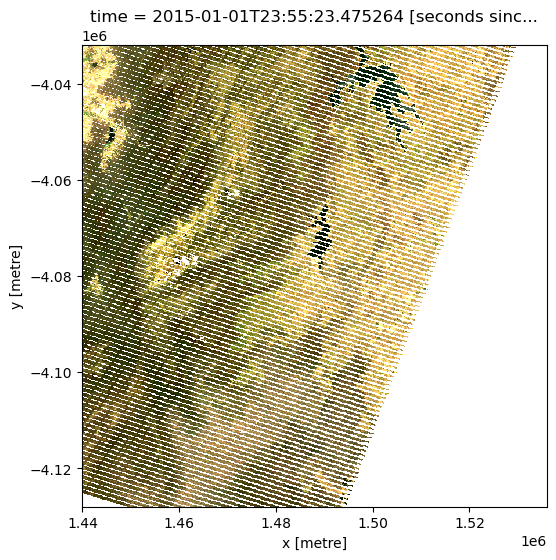

In [188]:
rgb(ds_filtered_stack, index=0)

### Use filtered ARD stack to calculate TC's on each scene, then calulate the percentiles from these

In [185]:
# should be able to make ds['green'] and do calculation on whole array. 
# set up 3 arrays, one with the different coeffs in them. Then can export the TCW, TCG, TCB Cogs somewhere for testing later on (so I don't need to run the notebook every time I'm working).

Note: when using the calculate_indices function, it is important to set the collection parameter correctly. This is because different satellite collections use different names for the same bands, which can lead to invalid results if not accounted for.

Make sure to calculate 'in place' tor educe memory usage for large datasets.

In [186]:
# calcualte TCG using band indices in dea_tools

ds_tc = calculate_indices(ds_filtered_stack, index=['TCW', 'TCB', 'TCG'], collection='ga_ls_3', inplace=True)

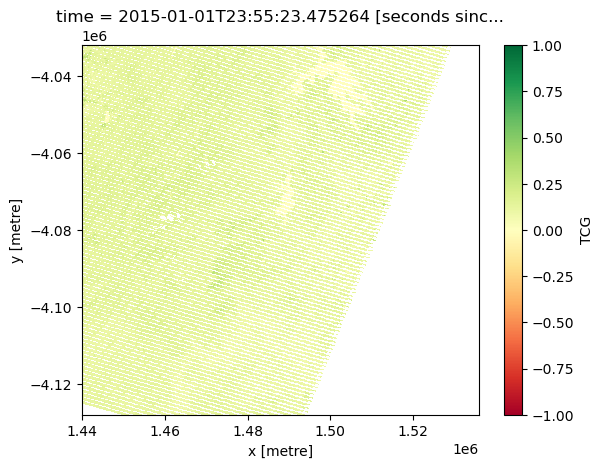

In [187]:
# Plot the results
ds_tc.TCG.isel(time=0).plot(vmin=-1, vmax=1, cmap='RdYlGn')